# CIC-IDS2017 - Feature Distribution Analysis

## Objectives

- Examine the distributions of numerical network-flow features
- Quantify skewness and feature ranges
- Identify highly skewed and extreme-valued features
- Analyze zero-dominated features
- Identify potential outliers and heavy-tailed features
- Compare selected feature distributions across traffic classes
- Visualize representative feature distributions
- Identify features that may require transformation or special handlind during preprocessing

> This notebook is descriptive only. No feature values are transformed, clipped, removed or imputed.

> **Sampling note:** The complete CIC-IDS2017 dataset contains 2,830,743 records. A reproducible 250,000-row sample (`random_state=42`) is used for computationally intensive distributional statistics and visualizations to avoid unnecessary memory overhead. Exact dataset-level counts are retained where computationally practical.

## 1. Imports and Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_DIR = Path("../data/raw/cicids2017")
RESULTS_DIR = Path("../results/cicids2017/04_feature_distribution")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"Found {len(csv_files)} CSV files")

Found 8 CSV files


## 2. Load CIC-IDS2017

In [3]:
dfs = {}

for file in csv_files:
    print(f"Loading: {file.name}")

    df = pd.read_csv(file, low_memory=False)
    df.columns = df.columns.str.strip()

    dfs[file.name] = df

print("\nLoaded files:")
for name, df in dfs.items():
    print(f"{name}: {df.shape}")

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv

Loaded files:
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 79)
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (286467, 79)
Friday-WorkingHours-Morning.pcap_ISCX.csv: (191033, 79)
Monday-WorkingHours.pcap_ISCX.csv: (529918, 79)
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (288602, 79)
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (170366, 79)
Tuesday-WorkingHours.pcap_ISCX.csv: (445909, 79)
Wednesday-workingHours.pcap_ISCX.csv: (692703, 79)


## 3. Combine datasets

In [4]:
data = pd.concat(
    [
        df.assign(source_file=name)
        for name, df in dfs.items()
    ],
    ignore_index=True
)

print("Combined shape:", data.shape)

Combined shape: (2830743, 80)


In [5]:
LABEL_COL = next(
    col for col in data.columns
    if "label" in col.lower()
)

print("Label column:", LABEL_COL)

Label column: Label


## 4. Numerical feature inventory

In [6]:
numeric_cols = data.select_dtypes(
    include=np.number
).columns.tolist()

print("Number of numerical columns:", len(numeric_cols))

Number of numerical columns: 78


Remove which are not to be considered as features

In [7]:
numeric_features = [
    col for col in numeric_cols
    if col not in []
]

print("Numerical features:", len(numeric_features))

Numerical features: 78


## 5. Basic Descriptive Statistics

In [8]:
feature_stats = data[numeric_features].describe().T
feature_stats

c:\Coding Stuff\CIC-Dataset-Analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Coding Stuff\CIC-Dataset-Analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0000,8071.4825,18283.6322,0.0000,53.0000,80.0000,443.0000,65535.0000
Flow Duration,2830743.0000,14785663.9295,33653744.0859,-13.0000,155.0000,31316.0000,3204828.5000,119999998.0000
Total Fwd Packets,2830743.0000,9.3612,749.6728,1.0000,2.0000,2.0000,5.0000,219759.0000
Total Backward Packets,2830743.0000,10.3938,997.3883,0.0000,1.0000,2.0000,4.0000,291922.0000
Total Length of Fwd Packets,2830743.0000,549.3024,9993.5892,0.0000,12.0000,62.0000,187.0000,12900000.0000
Total Length of Bwd Packets,2830743.0000,16162.6425,2263088.0517,0.0000,0.0000,123.0000,482.0000,655453030.0000
Fwd Packet Length Max,2830743.0000,207.5999,717.1848,0.0000,6.0000,37.0000,81.0000,24820.0000
Fwd Packet Length Min,2830743.0000,18.7137,60.3393,0.0000,0.0000,2.0000,36.0000,2325.0000
Fwd Packet Length Mean,2830743.0000,58.2019,186.0912,0.0000,6.0000,34.0000,50.0000,5940.8571
Fwd Packet Length Std,2830743.0000,68.9101,281.1871,0.0000,0.0000,0.0000,26.1630,7125.5968


In [10]:
feature_stats["missing_count"] = (
    data[numeric_features].isna().sum()
)

feature_stats["missing_percentage"] = (
    data[numeric_features].isna().mean() * 100
)

feature_stats["zero_count"] = (
    (data[numeric_features] == 0).sum()
)

feature_stats["zero_percentage"] = (
    (data[numeric_features] == 0).mean() * 100
)

feature_stats

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percentage,zero_count,zero_percentage
Destination Port,2830743.0000,8071.4825,18283.6322,0.0000,53.0000,80.0000,443.0000,65535.0000,0,0.0000,1696,0.0599
Flow Duration,2830743.0000,14785663.9295,33653744.0859,-13.0000,155.0000,31316.0000,3204828.5000,119999998.0000,0,0.0000,2867,0.1013
Total Fwd Packets,2830743.0000,9.3612,749.6728,1.0000,2.0000,2.0000,5.0000,219759.0000,0,0.0000,0,0.0000
Total Backward Packets,2830743.0000,10.3938,997.3883,0.0000,1.0000,2.0000,4.0000,291922.0000,0,0.0000,453519,16.0212
Total Length of Fwd Packets,2830743.0000,549.3024,9993.5892,0.0000,12.0000,62.0000,187.0000,12900000.0000,0,0.0000,449170,15.8676
Total Length of Bwd Packets,2830743.0000,16162.6425,2263088.0517,0.0000,0.0000,123.0000,482.0000,655453030.0000,0,0.0000,707746,25.0021
Fwd Packet Length Max,2830743.0000,207.5999,717.1848,0.0000,6.0000,37.0000,81.0000,24820.0000,0,0.0000,449170,15.8676
Fwd Packet Length Min,2830743.0000,18.7137,60.3393,0.0000,0.0000,2.0000,36.0000,2325.0000,0,0.0000,1317226,46.5329
Fwd Packet Length Mean,2830743.0000,58.2019,186.0912,0.0000,6.0000,34.0000,50.0000,5940.8571,0,0.0000,449170,15.8676
Fwd Packet Length Std,2830743.0000,68.9101,281.1871,0.0000,0.0000,0.0000,26.1630,7125.5968,0,0.0000,1850684,65.3780


## 6. Add Skewness

In [12]:
feature_stats = data[numeric_features].describe().T

feature_stats["missing_count"] = data[numeric_features].isna().sum()
feature_stats["missing_percentage"] = (
    feature_stats["missing_count"] / len(data) * 100
)

feature_stats["zero_count"] = (
    data[numeric_features] == 0
).sum()

feature_stats["zero_percentage"] = (
    feature_stats["zero_count"] / len(data) * 100
)

feature_stats["skewness"] = np.nan
feature_stats["kurtosis"] = np.nan

for col in numeric_features:
    # Work on one column at a time
    values = data[col]

    # Remove inf only for statistical calculation
    values = values.replace([np.inf, -np.inf], np.nan)

    feature_stats.loc[col, "skewness"] = values.skew()
    feature_stats.loc[col, "kurtosis"] = values.kurtosis()

feature_stats

c:\Coding Stuff\CIC-Dataset-Analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Coding Stuff\CIC-Dataset-Analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percentage,zero_count,zero_percentage,skewness,kurtosis
Destination Port,2830743.0000,8071.4825,18283.6322,0.0000,53.0000,80.0000,443.0000,65535.0000,0,0.0000,1696,0.0599,2.0721,2.5182
Flow Duration,2830743.0000,14785663.9295,33653744.0859,-13.0000,155.0000,31316.0000,3204828.5000,119999998.0000,0,0.0000,2867,0.1013,2.1554,3.0203
Total Fwd Packets,2830743.0000,9.3612,749.6728,1.0000,2.0000,2.0000,5.0000,219759.0000,0,0.0000,0,0.0000,244.3806,61754.4313
Total Backward Packets,2830743.0000,10.3938,997.3883,0.0000,1.0000,2.0000,4.0000,291922.0000,0,0.0000,453519,16.0212,244.6795,62017.9755
Total Length of Fwd Packets,2830743.0000,549.3024,9993.5892,0.0000,12.0000,62.0000,187.0000,12900000.0000,0,0.0000,449170,15.8676,805.5705,988552.6199
Total Length of Bwd Packets,2830743.0000,16162.6425,2263088.0517,0.0000,0.0000,123.0000,482.0000,655453030.0000,0,0.0000,707746,25.0021,244.3309,61601.6523
Fwd Packet Length Max,2830743.0000,207.5999,717.1848,0.0000,6.0000,37.0000,81.0000,24820.0000,0,0.0000,449170,15.8676,9.8492,136.7458
Fwd Packet Length Min,2830743.0000,18.7137,60.3393,0.0000,0.0000,2.0000,36.0000,2325.0000,0,0.0000,1317226,46.5329,20.1392,476.5584
Fwd Packet Length Mean,2830743.0000,58.2019,186.0912,0.0000,6.0000,34.0000,50.0000,5940.8571,0,0.0000,449170,15.8676,9.1358,94.9351
Fwd Packet Length Std,2830743.0000,68.9101,281.1871,0.0000,0.0000,0.0000,26.1630,7125.5968,0,0.0000,1850684,65.3780,10.5311,139.9511


In [22]:
feature_stats["skewness"] = np.nan
feature_stats["kurtosis"] = np.nan

for col in numeric_features:
    values = data[col].to_numpy(copy=False)

    values = values[np.isfinite(values)]

    n = len(values)

    mean = values.mean()
    std = values.std(ddof=1)

    if std == 0:
        skew = 0
        kurtosis = 0
    else:
        centered = values - mean

        skew = (
            (n / ((n - 1) * (n - 2)))
            * np.sum((centered / std) ** 3)
        )

        kurtosis = (
            (
                n * (n + 1)
                / ((n - 1) * (n - 2) * (n - 3))
            )
            * np.sum((centered / std) ** 4)
            - (3 * (n - 1) ** 2)
            / ((n - 2) * (n - 3))
        )

    feature_stats.loc[col, "skewness"] = skew
    feature_stats.loc[col, "kurtosis"] = kurtosis

feature_stats

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percentage,zero_count,zero_percentage,skewness,kurtosis,max_to_median_ratio
Destination Port,2830743.0000,8071.4825,18283.6322,0.0000,53.0000,80.0000,443.0000,65535.0000,0,0.0000,1696,0.0599,2.0721,2.5182,819.1875
Flow Duration,2830743.0000,14785663.9295,33653744.0859,-13.0000,155.0000,31316.0000,3204828.5000,119999998.0000,0,0.0000,2867,0.1013,2.1554,3.0203,3831.9069
Total Fwd Packets,2830743.0000,9.3612,749.6728,1.0000,2.0000,2.0000,5.0000,219759.0000,0,0.0000,0,0.0000,244.3806,61754.4313,109879.5000
Total Backward Packets,2830743.0000,10.3938,997.3883,0.0000,1.0000,2.0000,4.0000,291922.0000,0,0.0000,453519,16.0212,244.6795,62017.9755,145961.0000
Total Length of Fwd Packets,2830743.0000,549.3024,9993.5892,0.0000,12.0000,62.0000,187.0000,12900000.0000,0,0.0000,449170,15.8676,805.5705,988552.6199,208064.5161
Total Length of Bwd Packets,2830743.0000,16162.6425,2263088.0517,0.0000,0.0000,123.0000,482.0000,655453030.0000,0,0.0000,707746,25.0021,244.3309,61601.6523,5328886.4228
Fwd Packet Length Max,2830743.0000,207.5999,717.1848,0.0000,6.0000,37.0000,81.0000,24820.0000,0,0.0000,449170,15.8676,9.8492,136.7458,670.8108
Fwd Packet Length Min,2830743.0000,18.7137,60.3393,0.0000,0.0000,2.0000,36.0000,2325.0000,0,0.0000,1317226,46.5329,20.1392,476.5584,1162.5000
Fwd Packet Length Mean,2830743.0000,58.2019,186.0912,0.0000,6.0000,34.0000,50.0000,5940.8571,0,0.0000,449170,15.8676,9.1358,94.9351,174.7311
Fwd Packet Length Std,2830743.0000,68.9101,281.1871,0.0000,0.0000,0.0000,26.1630,7125.5968,0,0.0000,1850684,65.3780,10.5311,139.9511,NaN


## 7. Identify highly skewed features

In [54]:
highly_skewed = (
    feature_stats[
        feature_stats["skewness"].abs() > 2
    ]
    .sort_values(
        "skewness",
        key=lambda x: x.abs(),
        ascending=False
    )
)

In [55]:
extremely_skewed = feature_stats[
    feature_stats["skewness"].abs() > 5
].sort_values(
    "skewness",
    key=lambda x: x.abs(),
    ascending=False
)

extremely_skewed[
    ["skewness", "kurtosis", "min", "50%", "max"]
]

,skewness,kurtosis,min,50%,max
act_data_pkt_fwd,295.7758,89537.6609,0.0000,1.0000,198058.0000
Subflow Bwd Packets,253.3714,65983.4315,0.0000,2.0000,281741.0000
Total Backward Packets,253.3714,65983.4315,0.0000,2.0000,281741.0000
Total Fwd Packets,253.0656,65771.8849,1.0000,2.0000,206687.0000
Subflow Fwd Packets,253.0656,65771.8849,1.0000,2.0000,206687.0000
Total Length of Bwd Packets,253.0600,65758.5015,0.0000,122.0000,607000000.0000
Subflow Bwd Bytes,253.0489,65749.9312,0.0000,122.0000,606685970.0000
Fwd Header Length.1,251.1571,65160.7901,0.0000,64.0000,4340524.0000
Fwd Header Length,251.1571,65160.7901,0.0000,64.0000,4340524.0000
Bwd Header Length,250.3038,64786.6467,0.0000,40.0000,5634820.0000


## 8. Zero Dominated Features

In [18]:
zero_dominated = (
    feature_stats[
        feature_stats["zero_percentage"] >= 90
    ]
    .sort_values(
        "zero_percentage",
        ascending=False
    )
)

zero_dominated[
    [
        "zero_count",
        "zero_percentage",
        "mean",
        "50%",
        "max"
    ]
]

,zero_count,zero_percentage,mean,50%,max
Bwd PSH Flags,2830743,100.0000,0.0000,0.0000,0.0000
Bwd URG Flags,2830743,100.0000,0.0000,0.0000,0.0000
Bwd Avg Bytes/Bulk,2830743,100.0000,0.0000,0.0000,0.0000
Fwd Avg Bulk Rate,2830743,100.0000,0.0000,0.0000,0.0000
Bwd Avg Bulk Rate,2830743,100.0000,0.0000,0.0000,0.0000
Bwd Avg Packets/Bulk,2830743,100.0000,0.0000,0.0000,0.0000
Fwd Avg Packets/Bulk,2830743,100.0000,0.0000,0.0000,0.0000
Fwd Avg Bytes/Bulk,2830743,100.0000,0.0000,0.0000,0.0000
CWE Flag Count,2830428,99.9889,0.0001,0.0000,1.0000
Fwd URG Flags,2830428,99.9889,0.0001,0.0000,1.0000


In [19]:
extreme_zero_dominated = (
    feature_stats[
        feature_stats["zero_percentage"] >= 90
    ]
    .sort_values(
        "zero_percentage",
        ascending=False
    )
)

extreme_zero_dominated[
    [
        "zero_count",
        "zero_percentage",
        "mean",
        "50%",
        "max"
    ]
]

,zero_count,zero_percentage,mean,50%,max
Bwd PSH Flags,2830743,100.0000,0.0000,0.0000,0.0000
Bwd URG Flags,2830743,100.0000,0.0000,0.0000,0.0000
Bwd Avg Bytes/Bulk,2830743,100.0000,0.0000,0.0000,0.0000
Fwd Avg Bulk Rate,2830743,100.0000,0.0000,0.0000,0.0000
Bwd Avg Bulk Rate,2830743,100.0000,0.0000,0.0000,0.0000
Bwd Avg Packets/Bulk,2830743,100.0000,0.0000,0.0000,0.0000
Fwd Avg Packets/Bulk,2830743,100.0000,0.0000,0.0000,0.0000
Fwd Avg Bytes/Bulk,2830743,100.0000,0.0000,0.0000,0.0000
CWE Flag Count,2830428,99.9889,0.0001,0.0000,1.0000
Fwd URG Flags,2830428,99.9889,0.0001,0.0000,1.0000


## 9. Range Analysis

In [20]:
feature_stats["max_to_median_ratio"] = (
    feature_stats["max"]
    /
    feature_stats["50%"].replace(0, np.nan)
)

range_extremes = feature_stats.sort_values(
    "max_to_median_ratio",
    ascending=False
)

range_extremes[
    [
        "min",
        "50%",
        "max",
        "max_to_median_ratio"
    ]
]

,min,50%,max,max_to_median_ratio
Flow Packets/s,-2000000.0000,110.6684,inf,inf
Flow Bytes/s,-261000000.0000,4595.5491,inf,inf
Bwd IAT Min,0.0000,1.0000,120000000.0000,120000000.0000
Bwd IAT Mean,0.0000,3.0000,120000000.0000,40000000.0000
Fwd IAT Min,-12.0000,3.0000,120000000.0000,40000000.0000
Bwd IAT Total,0.0000,3.0000,120000000.0000,40000000.0000
Bwd IAT Max,0.0000,3.0000,120000000.0000,40000000.0000
Flow IAT Min,-14.0000,4.0000,120000000.0000,30000000.0000
Subflow Bwd Bytes,0.0000,123.0000,655453030.0000,5328886.4228
Total Length of Bwd Packets,0.0000,123.0000,655453030.0000,5328886.4228


## 10. Percentile Analysis

In [23]:
SAMPLE_SIZE = 250_000

sample = data.sample(
    n=min(SAMPLE_SIZE, len(data)),
    random_state=42
)

print("Full dataset:", data.shape)
print("Distribution sample:", sample.shape)

Full dataset: (2830743, 80)
Distribution sample: (250000, 80)


In [24]:
sample_numeric = sample[numeric_features]

In [53]:
feature_stats = (
    sample[numeric_features]
    .describe()
    .T
)

feature_stats["missing_count"] = (
    sample[numeric_features].isna().sum()
)

feature_stats["missing_percentage"] = (
    feature_stats["missing_count"] / len(sample) * 100
)

feature_stats["zero_count"] = (
    sample[numeric_features] == 0
).sum()

feature_stats["zero_percentage"] = (
    feature_stats["zero_count"] / len(sample) * 100
)

feature_stats["skewness"] = np.nan
feature_stats["kurtosis"] = np.nan

for col in numeric_features:
    values = (
        sample[col]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    feature_stats.loc[col, "skewness"] = values.skew()
    feature_stats.loc[col, "kurtosis"] = values.kurtosis()

feature_stats

c:\Coding Stuff\CIC-Dataset-Analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Coding Stuff\CIC-Dataset-Analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percentage,zero_count,zero_percentage,skewness,kurtosis
Destination Port,250000.0000,8119.1620,18327.9964,0.0000,53.0000,80.0000,443.0000,65534.0000,0,0.0000,150,0.0600,2.0612,2.4716
Flow Duration,250000.0000,14707169.8954,33571969.5508,-1.0000,154.0000,31296.0000,3090775.2500,119999977.0000,0,0.0000,272,0.1088,2.1654,3.0669
Total Fwd Packets,250000.0000,9.0246,696.0698,1.0000,2.0000,2.0000,5.0000,206687.0000,0,0.0000,0,0.0000,253.0656,65771.8849
Total Backward Packets,250000.0000,10.0253,946.5435,0.0000,1.0000,2.0000,4.0000,281741.0000,0,0.0000,40367,16.1468,253.3714,65983.4315
Total Length of Fwd Packets,250000.0000,546.7639,6339.9202,0.0000,6.0000,62.0000,187.0000,1827335.0000,0,0.0000,39892,15.9568,168.5817,39267.5884
Total Length of Bwd Packets,250000.0000,14951.8030,2043376.3150,0.0000,0.0000,122.0000,481.0000,607000000.0000,0,0.0000,62718,25.0872,253.0600,65758.5015
Fwd Packet Length Max,250000.0000,207.6884,714.3219,0.0000,6.0000,37.0000,81.0000,24820.0000,0,0.0000,39892,15.9568,9.8926,142.3063
Fwd Packet Length Min,250000.0000,18.7063,60.4549,0.0000,0.0000,2.0000,36.0000,2065.0000,0,0.0000,116292,46.5168,20.0545,473.0383
Fwd Packet Length Mean,250000.0000,58.3940,187.1738,0.0000,6.0000,34.0000,50.0000,4672.0000,0,0.0000,39892,15.9568,9.1168,94.6875
Fwd Packet Length Std,250000.0000,68.9840,279.8760,0.0000,0.0000,0.0000,26.1630,7125.5968,0,0.0000,163769,65.5076,10.4424,138.3177


Exact counts and percentages are calculated using the complete dataset. Computationally expensive distributional statistics and visualizations are calculated using a reproducible 250,000-row sample.

In [26]:
percentiles = (
    sample[numeric_features]
    .replace([np.inf, -np.inf], np.nan)
    .quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    .T
)

percentiles.head()

,0.0100,0.0500,0.2500,0.5000,0.7500,0.9500,0.9900
Destination Port,22.0000,53.0000,53.0000,80.0000,443.0000,55239.0000,61642.0600
Flow Duration,1.0000,4.0000,154.0000,31296.0000,3090775.2500,101080558.7500,117789962.4800
Total Fwd Packets,1.0000,1.0000,2.0000,2.0000,5.0000,19.0000,48.0000
Total Backward Packets,0.0000,0.0000,1.0000,2.0000,4.0000,17.0000,57.0000
Total Length of Fwd Packets,0.0000,0.0000,6.0000,62.0000,187.0000,1786.0000,11595.0000


In [27]:
percentiles["iqr"] = (
    percentiles[0.75] -
    percentiles[0.25]
)

percentiles["p99_p50_ratio"] = (
    percentiles[0.99] /
    percentiles[0.50].replace(0, np.nan)
)

percentiles.sort_values(
    "p99_p50_ratio",
    ascending=False
).head(20)

,0.0100,0.0500,0.2500,0.5000,0.7500,0.9500,0.9900,iqr,p99_p50_ratio
Bwd IAT Min,0.0000,0.0000,0.0000,1.0000,44.0000,798.0000,45036267.7500,44.0000,45036267.7500
Bwd IAT Total,0.0000,0.0000,0.0000,3.0000,95965.0000,99700000.0000,117000000.0000,95965.0000,39000000.0000
Bwd IAT Max,0.0000,0.0000,0.0000,3.0000,59163.0000,25601559.8500,98700000.0000,59163.0000,32900000.0000
Bwd IAT Mean,0.0000,0.0000,0.0000,3.0000,17795.8929,8034697.8393,51800000.0000,17795.8929,17266666.6667
Fwd IAT Min,0.0000,0.0000,0.0000,3.0000,48.0000,35120.1000,49500000.0000,48.0000,16500000.0000
Fwd IAT Total,0.0000,0.0000,0.0000,26.0000,1175510.0000,101000000.0000,118000000.0000,1175510.0000,4538461.5385
Fwd IAT Max,0.0000,0.0000,0.0000,23.0000,875503.2500,84700000.0000,99900000.0000,875503.2500,4343478.2609
Fwd IAT Mean,0.0000,0.0000,0.0000,19.0000,194264.0357,14300000.0000,51458604.1400,194264.0357,2708347.5863
Flow IAT Std,0.0000,0.0000,0.0000,135.1018,669172.9943,24600000.0000,32700539.7538,669172.9943,242043.6774
Flow IAT Min,0.0000,1.0000,3.0000,4.0000,64.0000,60868.0000,600015.0600,61.0000,150003.7650


## 11. Extreme-Value / IQR Analysis

In [29]:
sample_finite = (
    sample[numeric_features]
    .replace([np.inf, -np.inf], np.nan)
)

In [47]:
highly_skewed = (
    feature_stats[
        feature_stats["skewness"].abs() > 2
    ]
    .sort_values(
        "skewness",
        key=lambda x: x.abs(),
        ascending=False
    )
)

highly_skewed[
    ["skewness", "kurtosis", "min", "50%", "max"]
]

,skewness,kurtosis,min,50%,max
act_data_pkt_fwd,295.7758,89537.6609,0.0000,1.0000,213557.0000
Total Backward Packets,253.3714,65983.4315,0.0000,2.0000,291922.0000
Subflow Bwd Packets,253.3714,65983.4315,0.0000,2.0000,291922.0000
Total Fwd Packets,253.0656,65771.8849,1.0000,2.0000,219759.0000
Subflow Fwd Packets,253.0656,65771.8849,1.0000,2.0000,219759.0000
Total Length of Bwd Packets,253.0600,65758.5015,0.0000,123.0000,655453030.0000
Subflow Bwd Bytes,253.0489,65749.9312,0.0000,123.0000,655453030.0000
Fwd Header Length,251.1571,65160.7901,-32212234632.0000,64.0000,4644908.0000
Fwd Header Length.1,251.1571,65160.7901,-32212234632.0000,64.0000,4644908.0000
Bwd Header Length,250.3038,64786.6467,-1073741320.0000,40.0000,5838440.0000


In [48]:
extremely_skewed = (
    feature_stats[
        feature_stats["skewness"].abs() > 5
    ]
    .sort_values(
        "skewness",
        key=lambda x: x.abs(),
        ascending=False
    )
)

extremely_skewed[
    ["skewness", "kurtosis", "min", "50%", "max"]
]

,skewness,kurtosis,min,50%,max
act_data_pkt_fwd,295.7758,89537.6609,0.0000,1.0000,213557.0000
Subflow Bwd Packets,253.3714,65983.4315,0.0000,2.0000,291922.0000
Total Backward Packets,253.3714,65983.4315,0.0000,2.0000,291922.0000
Total Fwd Packets,253.0656,65771.8849,1.0000,2.0000,219759.0000
Subflow Fwd Packets,253.0656,65771.8849,1.0000,2.0000,219759.0000
Total Length of Bwd Packets,253.0600,65758.5015,0.0000,123.0000,655453030.0000
Subflow Bwd Bytes,253.0489,65749.9312,0.0000,123.0000,655453030.0000
Fwd Header Length.1,251.1571,65160.7901,-32212234632.0000,64.0000,4644908.0000
Fwd Header Length,251.1571,65160.7901,-32212234632.0000,64.0000,4644908.0000
Bwd Header Length,250.3038,64786.6467,-1073741320.0000,40.0000,5838440.0000


In [30]:
Q1 = sample_finite.quantile(0.25)
Q3 = sample_finite.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [31]:
outlier_counts = pd.DataFrame(index=numeric_features)

outlier_counts["lower_outliers"] = (
    sample_finite.lt(lower_bound)
).sum()

outlier_counts["upper_outliers"] = (
    sample_finite.gt(upper_bound)
).sum()

outlier_counts["total_outliers"] = (
    outlier_counts["lower_outliers"] +
    outlier_counts["upper_outliers"]
)

outlier_counts["outlier_percentage"] = (
    outlier_counts["total_outliers"] /
    len(sample) * 100
)

outlier_counts.sort_values(
    "outlier_percentage",
    ascending=False
).head(20)

,lower_outliers,upper_outliers,total_outliers,outlier_percentage
Fwd IAT Mean,0,59545,59545,23.8180
Fwd IAT Total,0,59057,59057,23.6228
Fwd IAT Max,0,58871,58871,23.5484
Fwd Packet Length Max,0,58570,58570,23.4280
Fwd Packet Length Std,0,58565,58565,23.4260
Fwd IAT Std,0,58386,58386,23.3544
Packet Length Variance,0,57863,57863,23.1452
Bwd Packet Length Std,0,57794,57794,23.1176
Bwd Packet Length Max,0,56281,56281,22.5124
Destination Port,0,55650,55650,22.2600


## 12. Distribution Visualizations

In [32]:
top_skewed_features = (
    feature_stats["skewness"]
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

top_skewed_features

['act_data_pkt_fwd',
 'Total Backward Packets',
 'Subflow Bwd Packets',
 'Subflow Fwd Packets',
 'Total Fwd Packets',
 'Total Length of Bwd Packets',
 'Subflow Bwd Bytes',
 'Fwd Header Length',
 'Fwd Header Length.1',
 'Bwd Header Length']

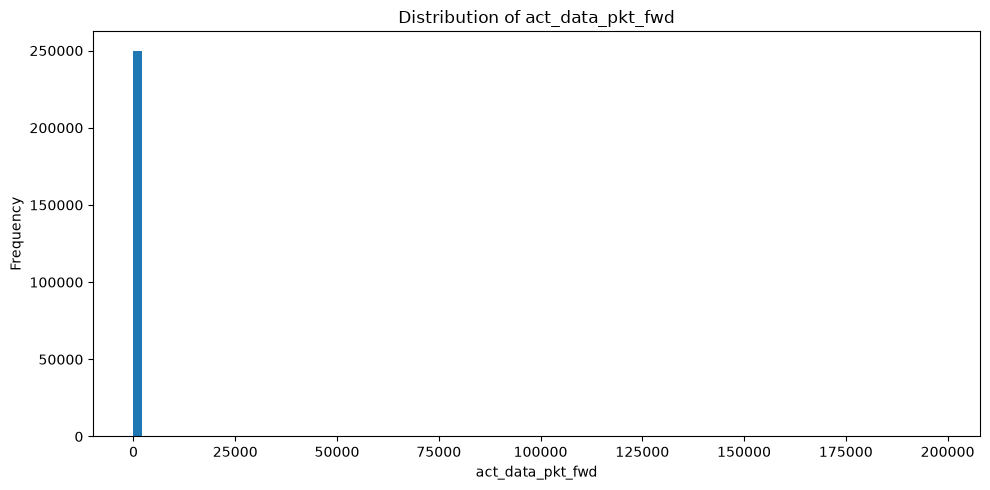

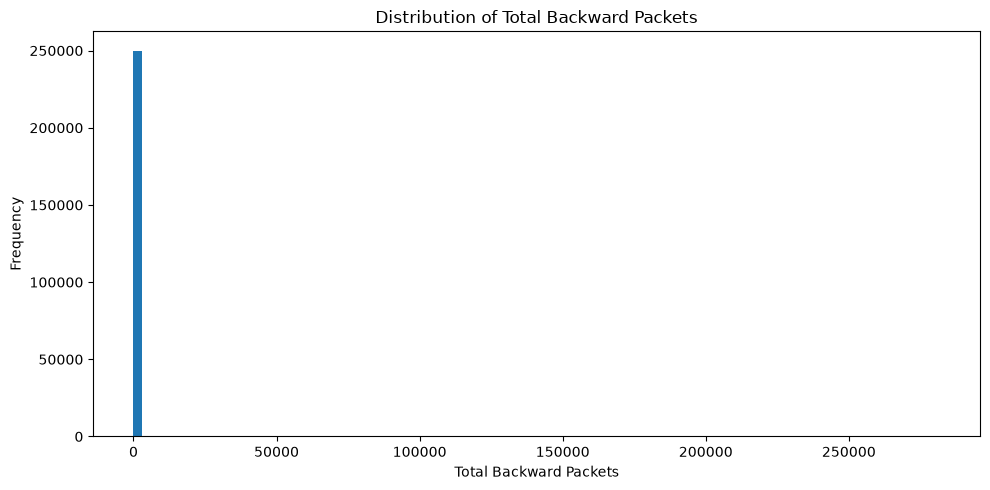

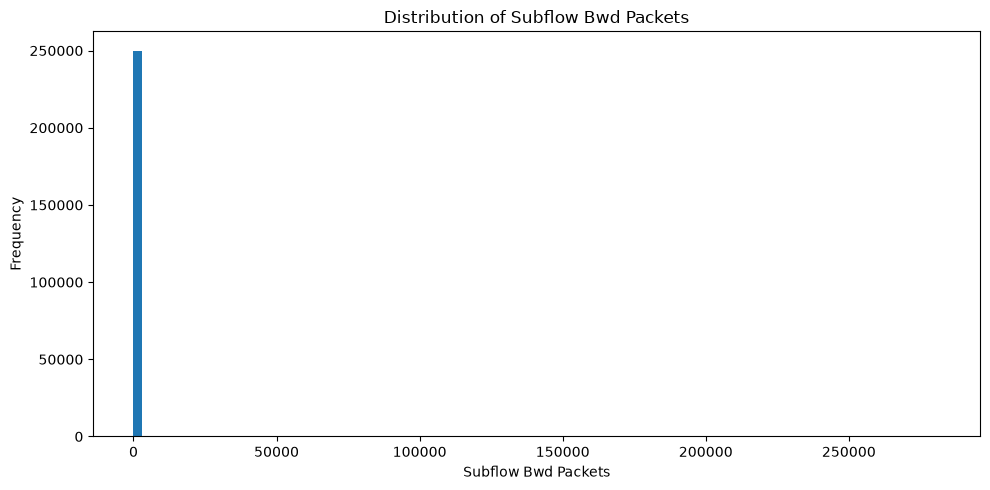

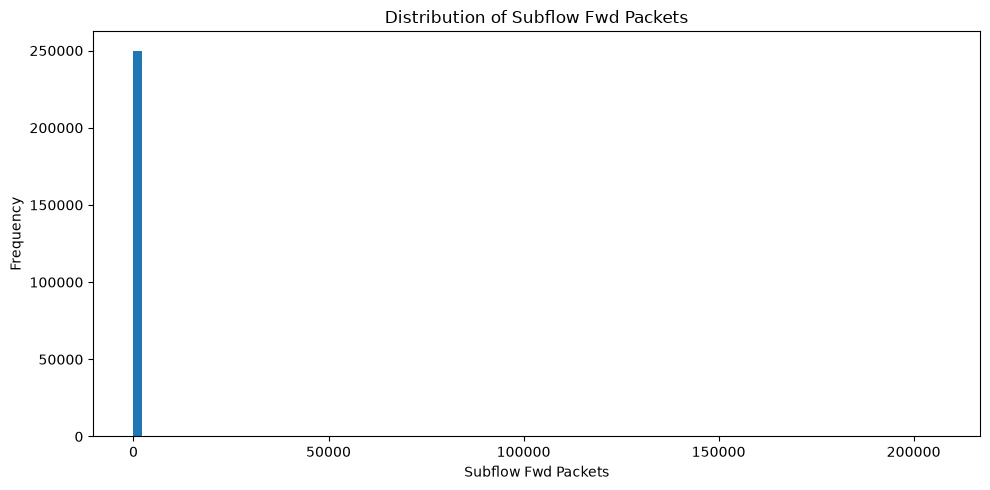

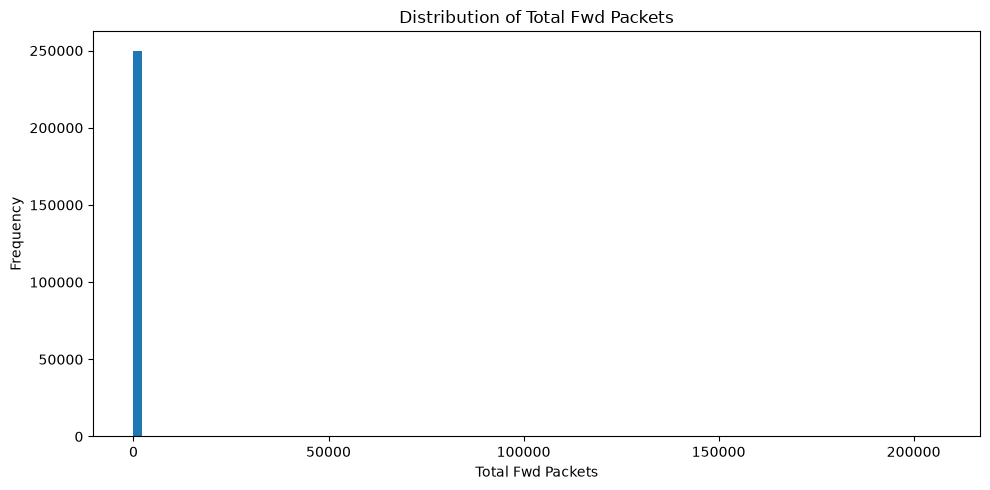

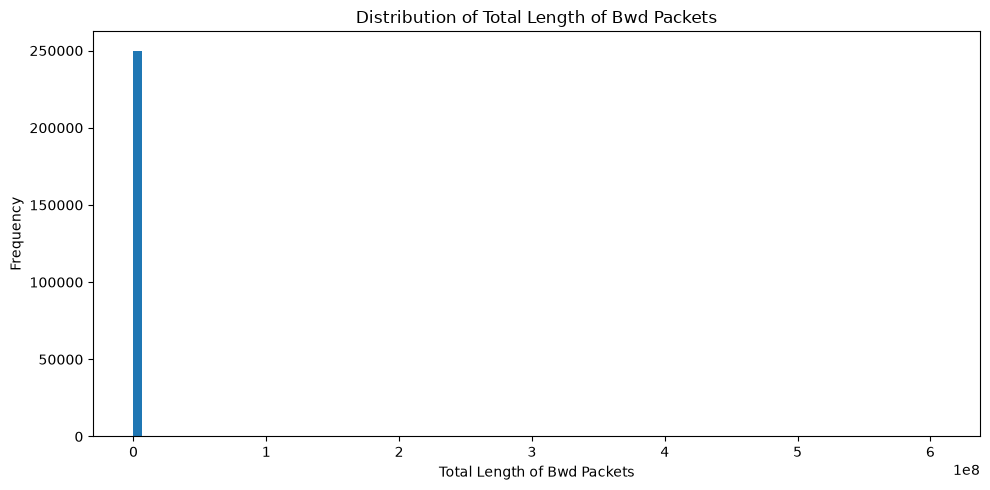

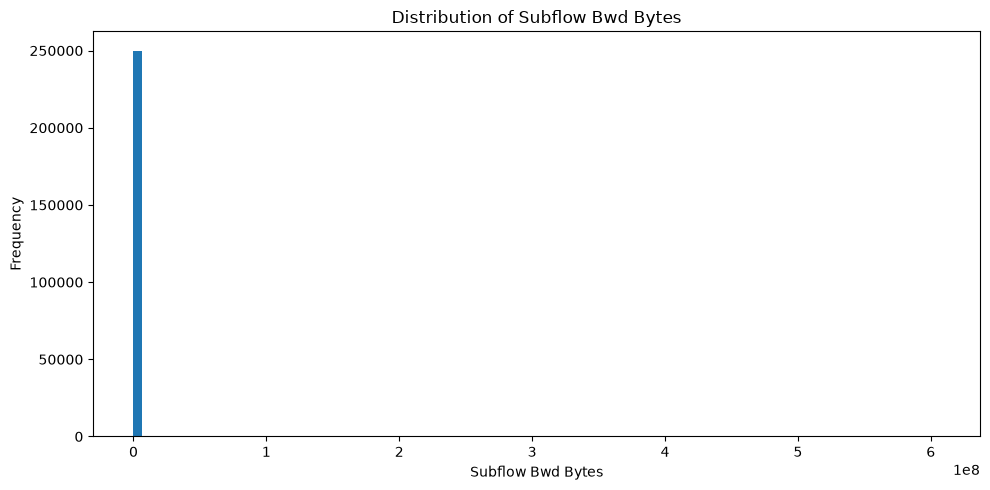

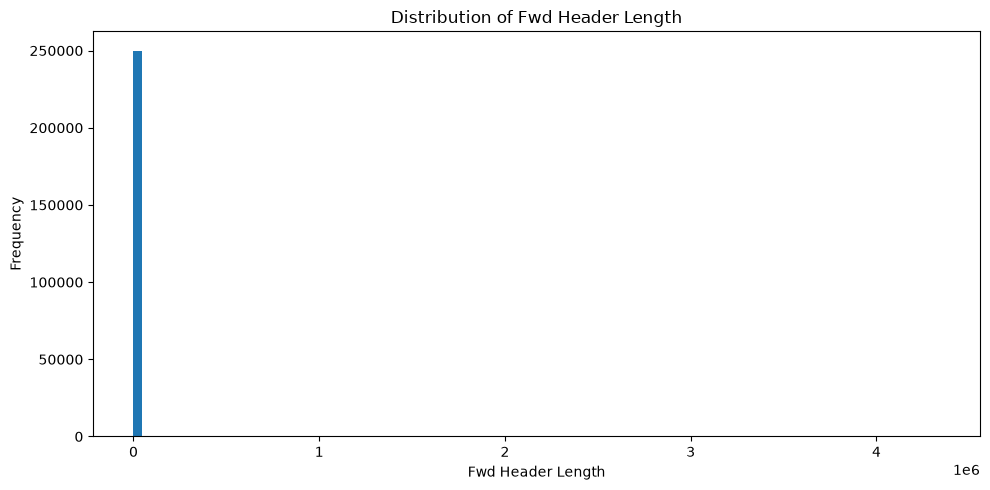

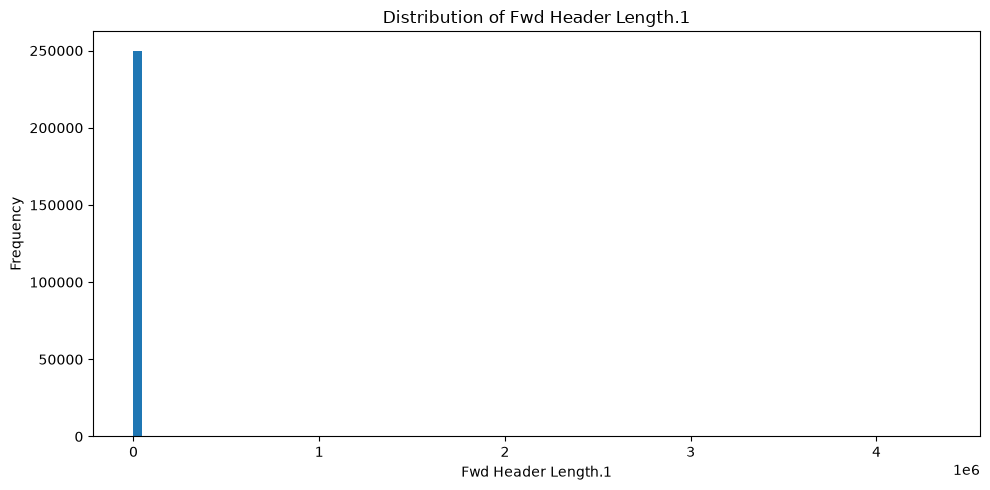

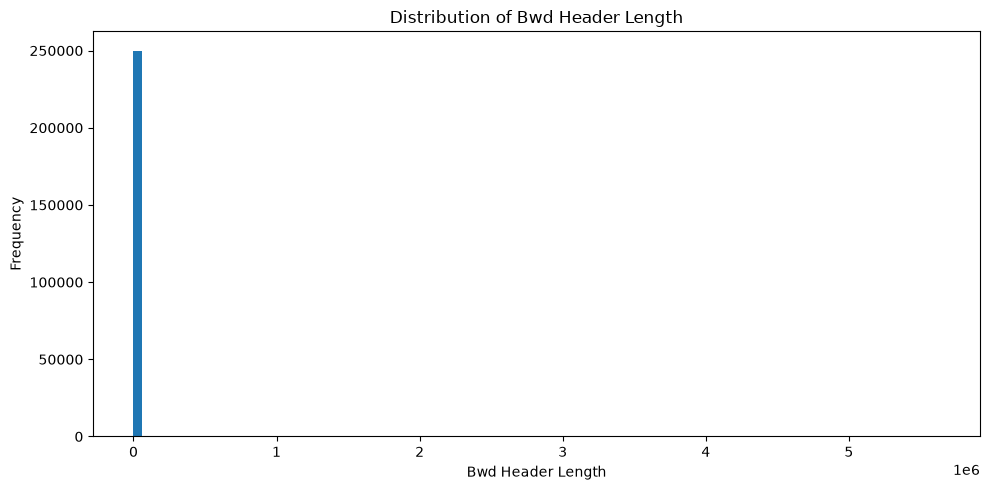

In [33]:
for col in top_skewed_features:
    values = (
        sample[col]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    plt.figure(figsize=(10, 5))

    plt.hist(
        values,
        bins=100
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

## 13. Log-Scale Visualizations

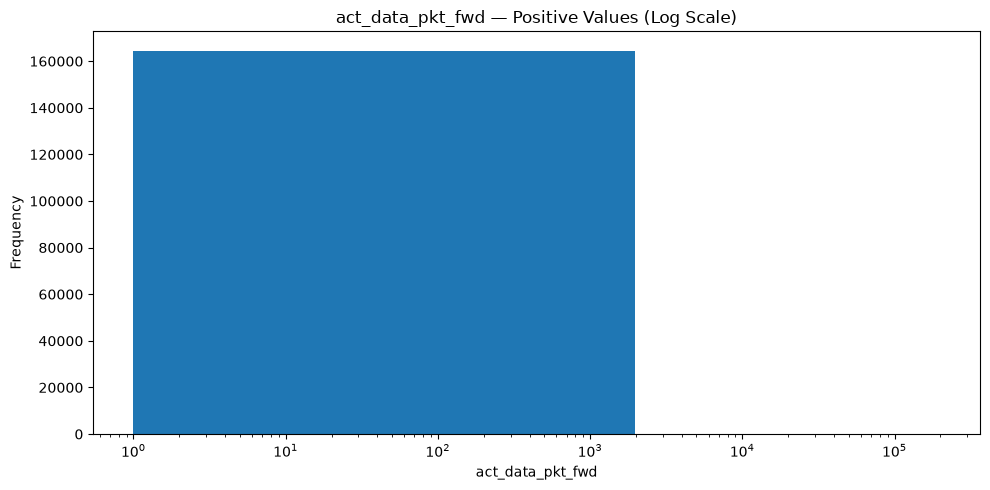

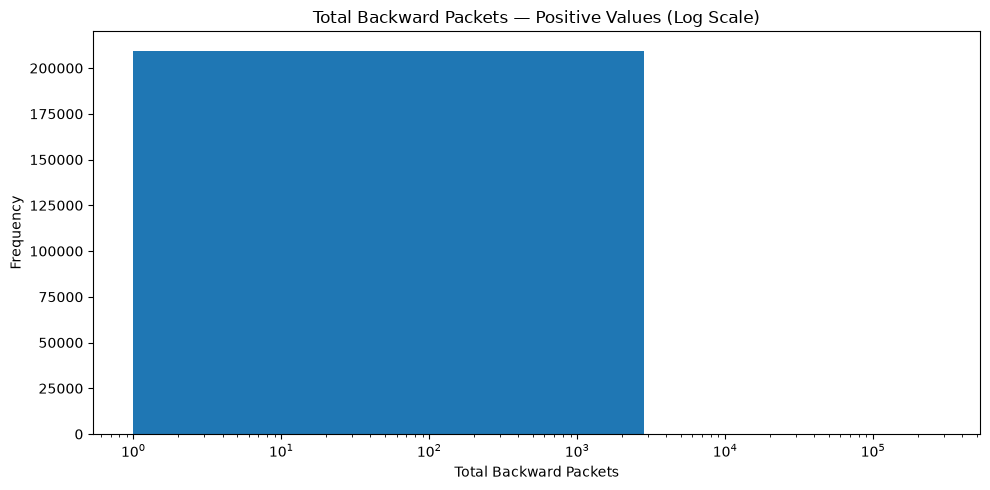

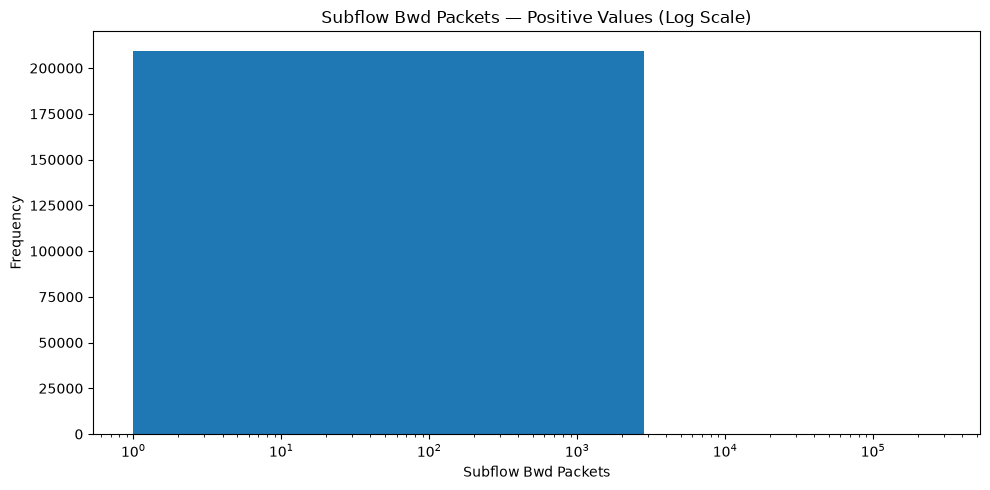

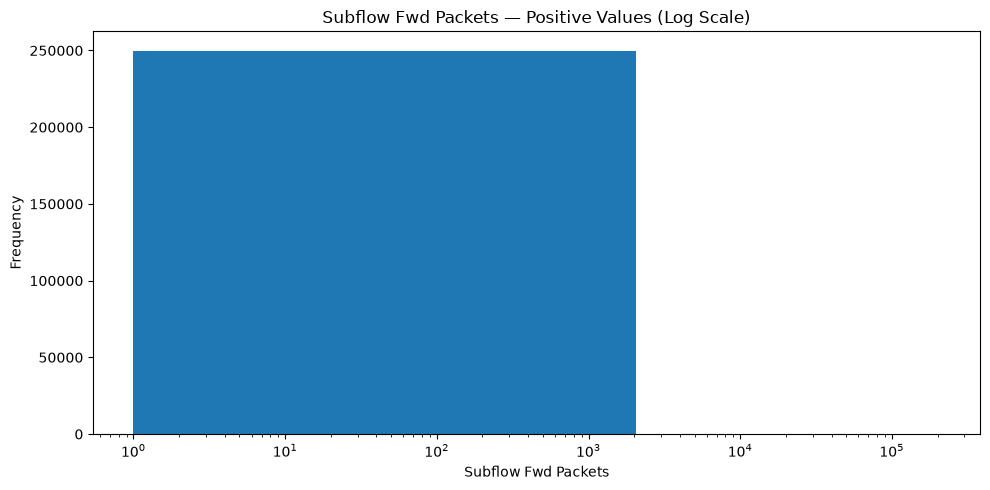

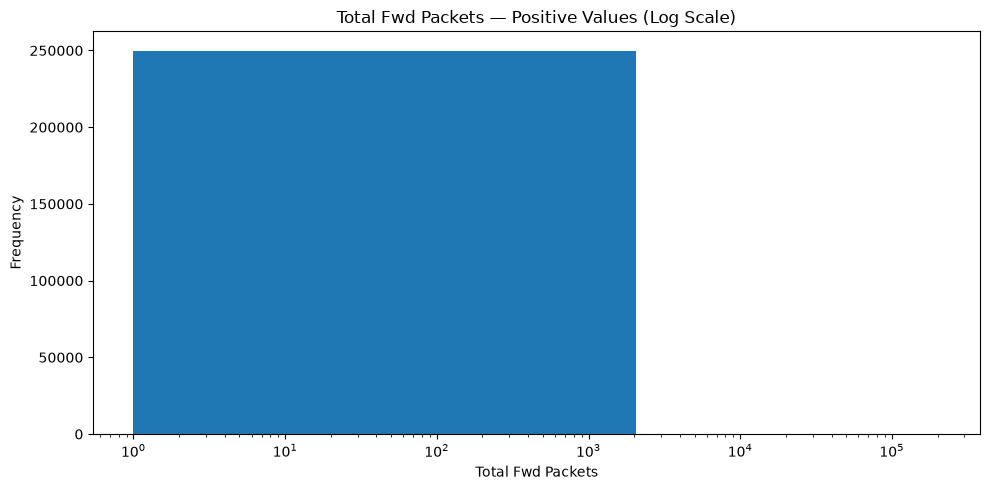

In [34]:
for col in top_skewed_features[:5]:

    values = (
        sample[col]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    positive_values = values[values > 0]

    plt.figure(figsize=(10, 5))

    plt.hist(
        positive_values,
        bins=100
    )

    plt.xscale("log")

    plt.title(
        f"{col} — Positive Values (Log Scale)"
    )
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

## 14. BENIGN vs ATTACK Distributions

In [35]:
data["traffic_type"] = np.where(
    data[LABEL_COL].str.upper() == "BENIGN",
    "BENIGN",
    "ATTACK"
)

In [36]:
sample["traffic_type"] = np.where(
    sample[LABEL_COL].str.upper() == "BENIGN",
    "BENIGN",
    "ATTACK"
)

In [37]:
representative_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s"
]

representative_features = [
    col for col in representative_features
    if col in sample.columns
]

representative_features

['Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Flow Bytes/s',
 'Flow Packets/s']

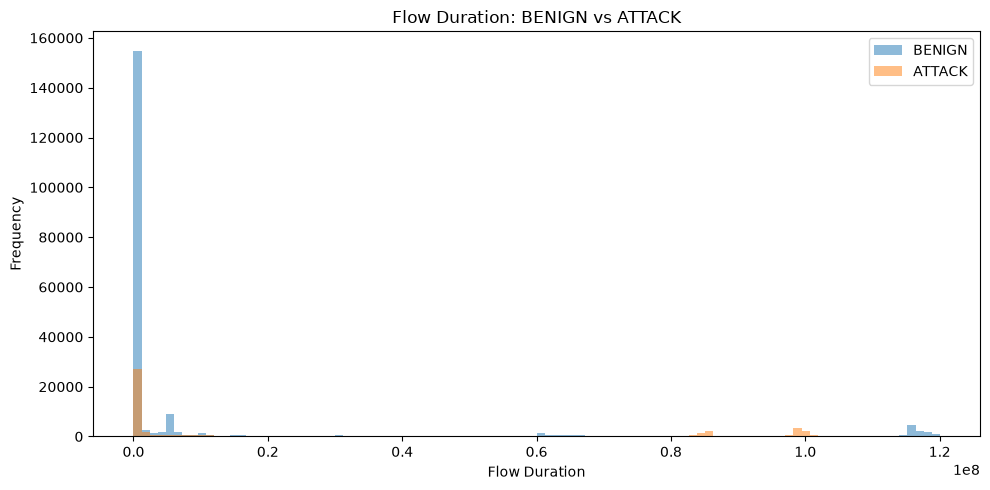

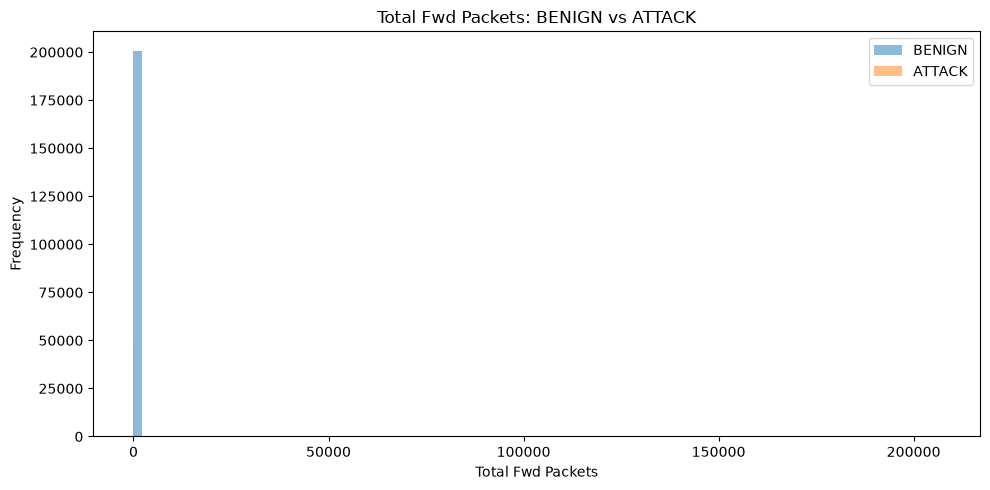

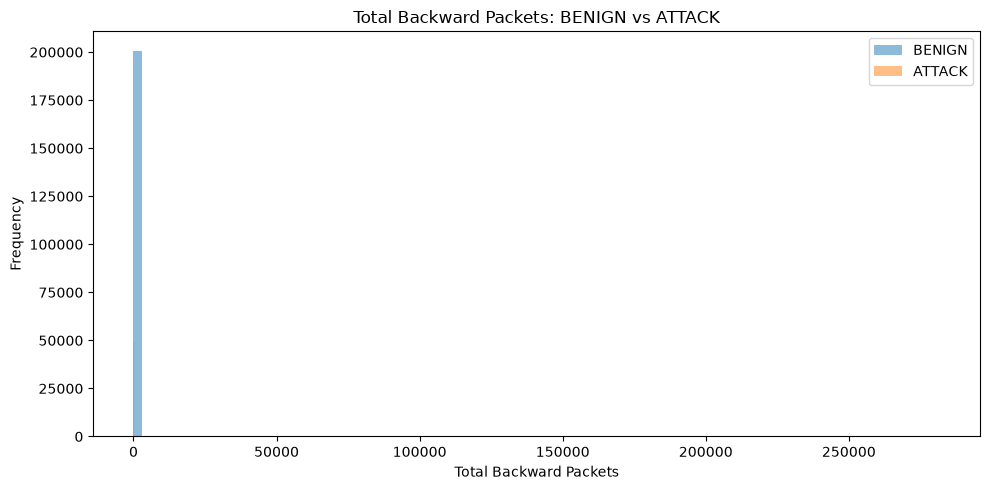

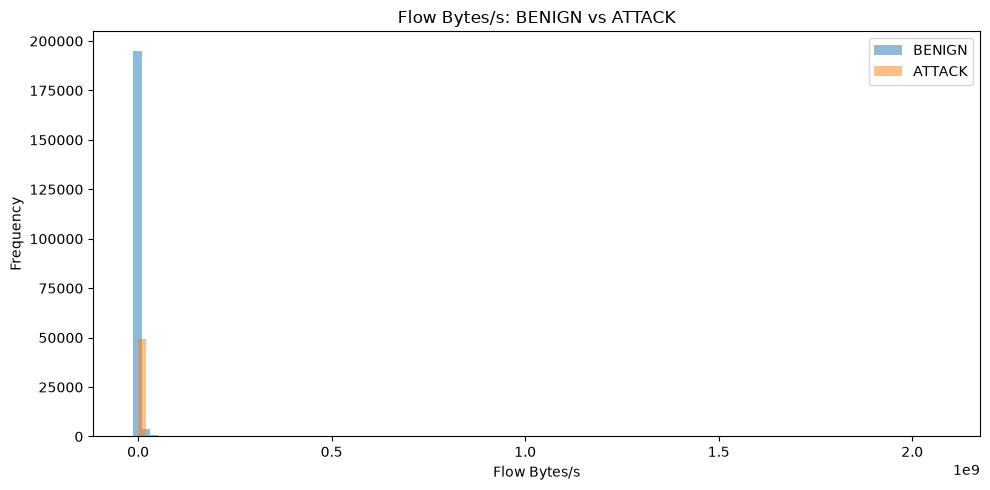

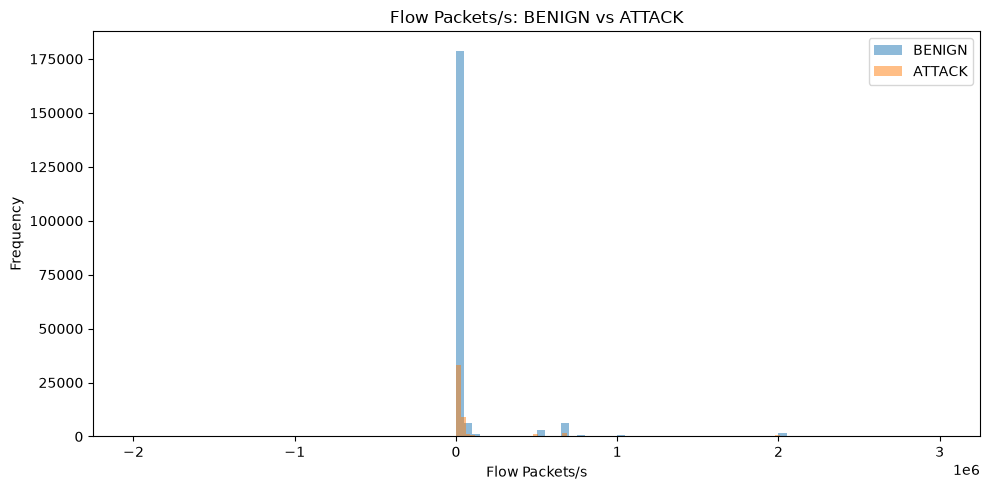

In [38]:
for col in representative_features:

    plt.figure(figsize=(10, 5))

    for traffic_type in ["BENIGN", "ATTACK"]:

        values = (
            sample.loc[
                sample["traffic_type"] == traffic_type,
                col
            ]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        plt.hist(
            values,
            bins=100,
            alpha=0.5,
            label=traffic_type
        )

    plt.title(
        f"{col}: BENIGN vs ATTACK"
    )
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()

    plt.tight_layout()
    plt.show()

## 15. Distribution Summary

In [49]:
distribution_report = feature_stats.copy()

distribution_report["skew_category"] = pd.cut(
    distribution_report["skewness"].abs(),
    bins=[
        -np.inf,
        0.5,
        1,
        2,
        5,
        np.inf
    ],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High",
        "Extreme"
    ]
)

distribution_report["zero_dominated"] = (
    distribution_report["zero_percentage"] >= 90
)

distribution_report["high_outlier_rate"] = (
    outlier_counts["outlier_percentage"] >= 5
)

distribution_report

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percentage,zero_count,zero_percentage,skewness,kurtosis,max_to_median_ratio,skew_category,zero_dominated,high_outlier_rate
Destination Port,2830743.0000,8071.4825,18283.6322,0.0000,53.0000,80.0000,443.0000,65535.0000,0,0.0000,1696,0.0599,2.0612,2.4716,819.1875,Very High,False,True
Flow Duration,2830743.0000,14785663.9295,33653744.0859,-13.0000,155.0000,31316.0000,3204828.5000,119999998.0000,0,0.0000,2867,0.1013,2.1654,3.0669,3831.9069,Very High,False,True
Total Fwd Packets,2830743.0000,9.3612,749.6728,1.0000,2.0000,2.0000,5.0000,219759.0000,0,0.0000,0,0.0000,253.0656,65771.8849,109879.5000,Extreme,False,True
Total Backward Packets,2830743.0000,10.3938,997.3883,0.0000,1.0000,2.0000,4.0000,291922.0000,0,0.0000,453519,16.0212,253.3714,65983.4315,145961.0000,Extreme,False,True
Total Length of Fwd Packets,2830743.0000,549.3024,9993.5892,0.0000,12.0000,62.0000,187.0000,12900000.0000,0,0.0000,449170,15.8676,168.5817,39267.5884,208064.5161,Extreme,False,True
Total Length of Bwd Packets,2830743.0000,16162.6425,2263088.0517,0.0000,0.0000,123.0000,482.0000,655453030.0000,0,0.0000,707746,25.0021,253.0600,65758.5015,5328886.4228,Extreme,False,True
Fwd Packet Length Max,2830743.0000,207.5999,717.1848,0.0000,6.0000,37.0000,81.0000,24820.0000,0,0.0000,449170,15.8676,9.8926,142.3063,670.8108,Extreme,False,True
Fwd Packet Length Min,2830743.0000,18.7137,60.3393,0.0000,0.0000,2.0000,36.0000,2325.0000,0,0.0000,1317226,46.5329,20.0545,473.0383,1162.5000,Extreme,False,False
Fwd Packet Length Mean,2830743.0000,58.2019,186.0912,0.0000,6.0000,34.0000,50.0000,5940.8571,0,0.0000,449170,15.8676,9.1168,94.6875,174.7311,Extreme,False,True
Fwd Packet Length Std,2830743.0000,68.9101,281.1871,0.0000,0.0000,0.0000,26.1630,7125.5968,0,0.0000,1850684,65.3780,10.4424,138.3177,NaN,Extreme,False,True


## 16. Export Results

In [50]:
feature_stats.to_csv(
    RESULTS_DIR / "feature_distribution_summary.csv"
)

percentiles.to_csv(
    RESULTS_DIR / "feature_percentiles.csv"
)

outlier_counts.to_csv(
    RESULTS_DIR / "feature_outlier_summary.csv"
)

highly_skewed.to_csv(
    RESULTS_DIR / "highly_skewed_features.csv"
)

zero_dominated.to_csv(
    RESULTS_DIR / "zero_dominated_features.csv"
)

distribution_report.to_csv(
    RESULTS_DIR / "feature_distribution_report.csv"
)

## 17. Sanity Checks

In [42]:
assert len(feature_stats) == len(numeric_features)

assert len(percentiles) == len(numeric_features)

assert len(outlier_counts) == len(numeric_features)

assert len(distribution_report) == len(numeric_features)

print("Feature distribution analysis checks passed.")

Feature distribution analysis checks passed.


In [44]:
print(f"Full dataset rows: {len(data):,}")
print(f"Distribution sample rows: {len(sample):,}")
print(f"Sample fraction: {len(sample) / len(data) * 100:.2f}%")

Full dataset rows: 2,830,743
Distribution sample rows: 250,000
Sample fraction: 8.83%


In [51]:
highly_skewed

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percentage,zero_count,zero_percentage,skewness,kurtosis,max_to_median_ratio
act_data_pkt_fwd,2830743.0000,5.4182,636.4257,0.0000,0.0000,1.0000,2.0000,213557.0000,0,0.0000,962924,34.0167,295.7758,89537.6609,213557.0000
Total Backward Packets,2830743.0000,10.3938,997.3883,0.0000,1.0000,2.0000,4.0000,291922.0000,0,0.0000,453519,16.0212,253.3714,65983.4315,145961.0000
Subflow Bwd Packets,2830743.0000,10.3938,997.3883,0.0000,1.0000,2.0000,4.0000,291922.0000,0,0.0000,453519,16.0212,253.3714,65983.4315,145961.0000
Total Fwd Packets,2830743.0000,9.3612,749.6728,1.0000,2.0000,2.0000,5.0000,219759.0000,0,0.0000,0,0.0000,253.0656,65771.8849,109879.5000
Subflow Fwd Packets,2830743.0000,9.3612,749.6728,1.0000,2.0000,2.0000,5.0000,219759.0000,0,0.0000,0,0.0000,253.0656,65771.8849,109879.5000
Total Length of Bwd Packets,2830743.0000,16162.6425,2263088.0517,0.0000,0.0000,123.0000,482.0000,655453030.0000,0,0.0000,707746,25.0021,253.0600,65758.5015,5328886.4228
Subflow Bwd Bytes,2830743.0000,16162.3025,2263057.2835,0.0000,0.0000,123.0000,482.0000,655453030.0000,0,0.0000,707746,25.0021,253.0489,65749.9312,5328886.4228
Fwd Header Length,2830743.0000,-25997.3920,21052857.8732,-32212234632.0000,40.0000,64.0000,120.0000,4644908.0000,0,0.0000,1758,0.0621,251.1571,65160.7901,72576.6875
Fwd Header Length.1,2830743.0000,-25997.3920,21052857.8732,-32212234632.0000,40.0000,64.0000,120.0000,4644908.0000,0,0.0000,1758,0.0621,251.1571,65160.7901,72576.6875
Bwd Header Length,2830743.0000,-2273.2753,1452208.9396,-1073741320.0000,20.0000,40.0000,104.0000,5838440.0000,0,0.0000,453651,16.0259,250.3038,64786.6467,145961.0000


In [52]:
outlier_counts.sort_values(
    "outlier_percentage",
    ascending=False
).head(10)

,lower_outliers,upper_outliers,total_outliers,outlier_percentage
Fwd IAT Mean,0,59545,59545,23.8180
Fwd IAT Total,0,59057,59057,23.6228
Fwd IAT Max,0,58871,58871,23.5484
Fwd Packet Length Max,0,58570,58570,23.4280
Fwd Packet Length Std,0,58565,58565,23.4260
Fwd IAT Std,0,58386,58386,23.3544
Packet Length Variance,0,57863,57863,23.1452
Bwd Packet Length Std,0,57794,57794,23.1176
Bwd Packet Length Max,0,56281,56281,22.5124
Destination Port,0,55650,55650,22.2600


In [56]:
print("Highly skewed:", (feature_stats["skewness"].abs() > 2).sum())
print("Extremely skewed:", (feature_stats["skewness"].abs() > 5).sum())
print("Zero dominated:", (feature_stats["zero_percentage"] >= 90).sum())
print("High IQR outlier rate:", (outlier_counts["outlier_percentage"] >= 5).sum())

highly_skewed.head(10)

Highly skewed: 67
Extremely skewed: 41
Zero dominated: 18
High IQR outlier rate: 56


,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percentage,zero_count,zero_percentage,skewness,kurtosis
act_data_pkt_fwd,250000.0000,5.1103,586.9491,0.0000,0.0000,1.0000,2.0000,198058.0000,0,0.0000,85399,34.1596,295.7758,89537.6609
Total Backward Packets,250000.0000,10.0253,946.5435,0.0000,1.0000,2.0000,4.0000,281741.0000,0,0.0000,40367,16.1468,253.3714,65983.4315
Subflow Bwd Packets,250000.0000,10.0253,946.5435,0.0000,1.0000,2.0000,4.0000,281741.0000,0,0.0000,40367,16.1468,253.3714,65983.4315
Total Fwd Packets,250000.0000,9.0246,696.0698,1.0000,2.0000,2.0000,5.0000,206687.0000,0,0.0000,0,0.0000,253.0656,65771.8849
Subflow Fwd Packets,250000.0000,9.0246,696.0698,1.0000,2.0000,2.0000,5.0000,206687.0000,0,0.0000,0,0.0000,253.0656,65771.8849
Total Length of Bwd Packets,250000.0000,14951.8030,2043376.3150,0.0000,0.0000,122.0000,481.0000,607000000.0000,0,0.0000,62718,25.0872,253.0600,65758.5015
Subflow Bwd Bytes,250000.0000,14950.4391,2043009.1738,0.0000,0.0000,122.0000,481.0000,606685970.0000,0,0.0000,62718,25.0872,253.0489,65749.9312
Fwd Header Length,250000.0000,222.4688,14637.7373,0.0000,40.0000,64.0000,120.0000,4340524.0000,0,0.0000,155,0.0620,251.1571,65160.7901
Fwd Header Length.1,250000.0000,222.4688,14637.7373,0.0000,40.0000,64.0000,120.0000,4340524.0000,0,0.0000,155,0.0620,251.1571,65160.7901
Bwd Header Length,250000.0000,239.6284,19019.1092,0.0000,20.0000,40.0000,104.0000,5634820.0000,0,0.0000,40379,16.1516,250.3038,64786.6467


## Conclusions

### Key Findings

1. **Strongly skewed feature distributions**
   - The numerical features exhibit substantial right-skewness and heavy-tailed behaviour.
   - The most strongly skewed features include `act_data_pkt_fwd`, `Total Backward Packets`, `Subflow Bwd Packets`, `Total Fwd Packets`, `Subflow Fwd Packets`, and packet/header-length features.
   - Several features have medians close to zero or very small values while their maximum values are orders of magnitude larger, demonstrating highly asymmetric distributions.

2. **Large feature ranges and extreme observations**
   - Several features exhibit extremely large differences between their central values and maximum observations.
   - For example, `Total Backward Packets` has a median of 2 but a maximum of 281,741, while `Total Length of Bwd Packets` has a median of 122 and a maximum exceeding 607 million.
   - These observations demonstrate that the raw feature space contains substantial scale variation and extreme values.

3. **Zero-dominated and sparse features**
   - A number of features contain a high proportion of zero-valued observations.
   - Combined with the strong skewness observed in several features, this indicates that the numerical feature space is not uniformly distributed and should not be treated with a single preprocessing assumption.

4. **IQR-based extreme values**
   - Several features contain substantial proportions of observations outside conventional IQR-based bounds.
   - These observations should not automatically be considered erroneous because network-flow data can naturally exhibit highly variable and heavy-tailed behaviour.
   - IQR-based detection is therefore useful for identifying extreme distributions, but not sufficient on its own to justify removing observations.

5. **Implications for preprocessing**
   - The observed distributions indicate that later preprocessing may require feature-specific handling of skewness, scale differences, extreme values, and zero-dominated distributions.
   - Transformations, scaling strategies, and treatment of suspicious values should be evaluated during the dedicated preprocessing stage rather than applied during exploratory analysis.

### Overall Assessment

CIC-IDS2017 exhibits substantial heterogeneity in the statistical behaviour of its numerical features. Many features are highly skewed, heavy-tailed, sparse, or characterized by extreme ranges. These properties reinforce the need for a feature-aware preprocessing strategy before machine-learning modelling.

This notebook establishes the statistical distribution baseline for CIC-IDS2017 and identifies the principal distributional characteristics that must be considered during subsequent preprocessing and ML suitability evaluation.

No feature values or observations were modified or removed during this analysis.